In [17]:
import pandas as pd
import networkx as nx
from pathlib import Path

data_dir = Path("data/01_raw")
processed_dir = Path("data/02_processed")
processed_dir.mkdir(parents=True, exist_ok=True)

print("⚙️ Starting batch network processing...")

# Find and sort all edge files chronologically
all_edge_files = sorted(list(data_dir.rglob("edges.parquet")))

for edge_file in all_edge_files:
    # Extract temporal data from folder structure
    year_val = edge_file.parts[-3].split('=')[1]
    day_val = edge_file.parts[-2].split('=')[1]
    
    output_path = processed_dir / f"metrics_{year_val}_{day_val}.parquet"
    
    # Skip if we already processed this snapshot
    if output_path.exists():
        continue
        
    # 1. Load Data
    edges_df = pd.read_parquet(edge_file)
    nodes_df = pd.read_parquet(edge_file.parent / "nodes.parquet")
    
    # 2. Build Graph & Inject Orphans
    G = nx.from_pandas_edgelist(edges_df, source='source_node', target='target_node', create_using=nx.DiGraph())
    G.add_nodes_from(nodes_df['node_name'].tolist())
    
    # 3. Calculate Math
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    pagerank = nx.pagerank(G)
    
    # Added Betweenness Centrality
    betweenness = nx.betweenness_centrality(G)
    
    bcc_nodes = max(nx.weakly_connected_components(G), key=len) if len(G) > 0 else set()
    in_bcc = {node: (node in bcc_nodes) for node in G.nodes()}
    
    # 4. Export
    metrics_df = pd.DataFrame({
        'node_name': list(G.nodes()),
        'year': int(year_val),
        'day_of_year': int(day_val),
        'in_degree': [in_degrees[n] for n in G.nodes()],
        'out_degree': [out_degrees[n] for n in G.nodes()],
        'pagerank': [pagerank[n] for n in G.nodes()],
        'betweenness': [betweenness[n] for n in G.nodes()],
        'is_in_bcc': [in_bcc[n] for n in G.nodes()]
    })
    
    metrics_df.to_parquet(output_path, index=False)
    print(f"✅ Processed Year {year_val}, Day {day_val} ({len(metrics_df)} nodes)")

print("🏁 Batch processing complete! Silver layer is fully loaded.")

⚙️ Starting batch network processing...
🏁 Batch processing complete! Silver layer is fully loaded.


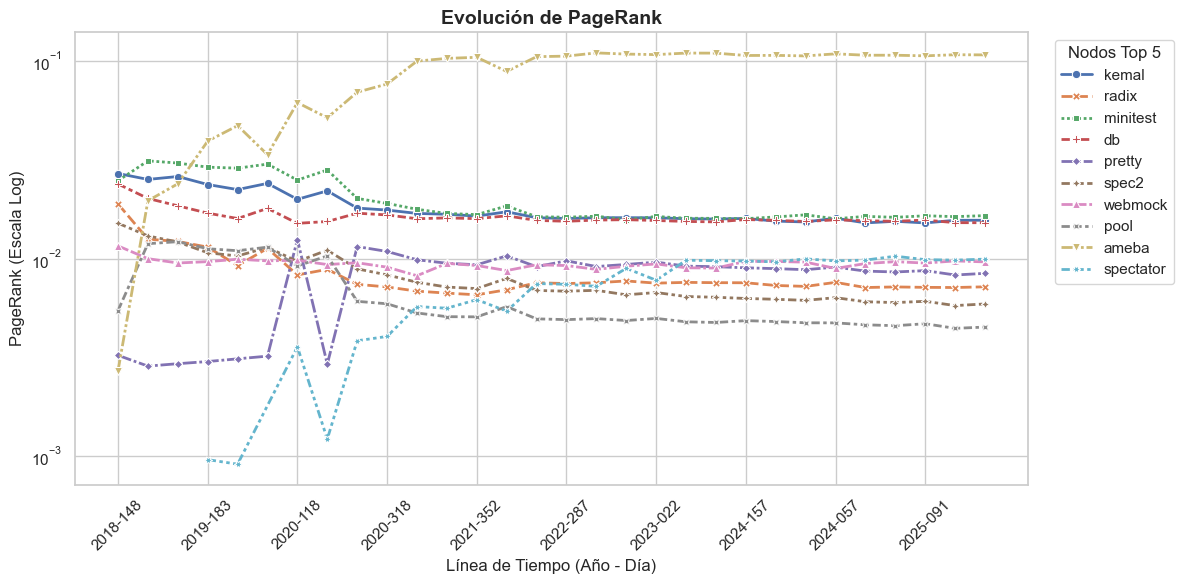

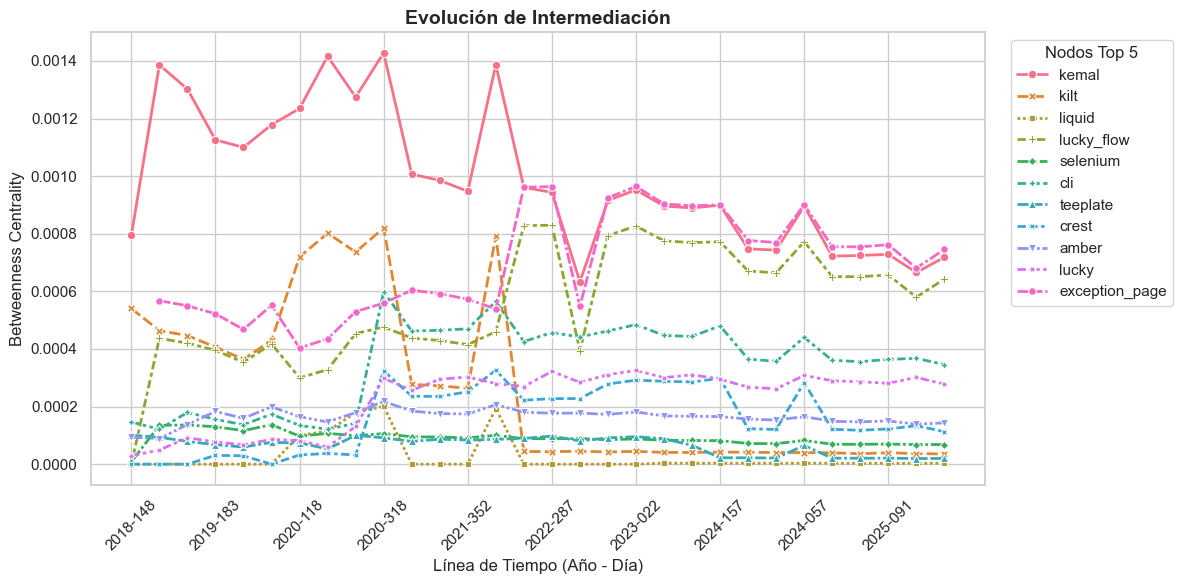

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Cargar Datos ---
processed_dir = Path("data/02_processed")
all_files = sorted(list(processed_dir.glob("metrics_*.parquet")))

df_list = [pd.read_parquet(f) for f in all_files]
df_temporal = pd.concat(df_list, ignore_index=True)
df_temporal['timeline'] = df_temporal['year'].astype(str) + "-" + df_temporal['day_of_year'].astype(str).str.zfill(3)

# --- 2. Extraer Nodos Históricos ---
historical_pr_nodes = df_temporal.groupby('timeline').apply(lambda x: x.nlargest(5, 'pagerank'))['node_name'].unique()
historical_bw_nodes = df_temporal.groupby('timeline').apply(lambda x: x.nlargest(5, 'betweenness'))['node_name'].unique()

pr_history = df_temporal[df_temporal['node_name'].isin(historical_pr_nodes)]
bw_history = df_temporal[df_temporal['node_name'].isin(historical_bw_nodes)]

sns.set_theme(style="whitegrid")

# Estrategia simple para el eje X: Mostrar solo ~8 etiquetas para no amontonar
fechas_unicas = df_temporal['timeline'].unique()
espaciado = max(1, len(fechas_unicas) // 8)

# --- 3. Gráfico A: PageRank (Escala Logarítmica) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pr_history, x='timeline', y='pagerank', 
    hue='node_name', style='node_name', 
    markers=True, dashes=True, linewidth=2
)

plt.yscale('log')
plt.title("Evolución de PageRank", fontsize=14, fontweight='bold')
plt.ylabel("PageRank (Escala Log)")
plt.xlabel("Línea de Tiempo (Año - Día)")

# Leyenda limpia afuera a la derecha
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Nodos Top 5")
# Eje X limpio
plt.xticks(ticks=fechas_unicas[::espaciado], rotation=45)

plt.tight_layout()
plt.show()

# --- 4. Gráfico B: Betweenness ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=bw_history, x='timeline', y='betweenness', 
    hue='node_name', style='node_name', 
    markers=True, dashes=True, linewidth=2
)

plt.title("Evolución de Intermediación", fontsize=14, fontweight='bold')
plt.ylabel("Betweenness Centrality")
plt.xlabel("Línea de Tiempo (Año - Día)")

# Leyenda limpia afuera a la derecha
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Nodos Top 5")
# Eje X limpio
plt.xticks(ticks=fechas_unicas[::espaciado], rotation=45)

plt.tight_layout()
plt.show()

# Exploring ameba cloud

In [19]:
# Find nodes pointing to 'ameba' where their total outgoing edges equal 1
ameba_satellites = [
    node for node in G.predecessors('ameba') 
    if G.out_degree(node) == 1
]

print(f"Found {len(ameba_satellites)} shards strictly dependent on Ameba:\n")
for shard in ameba_satellites:
    print(f"- {shard}")

Found 110 shards strictly dependent on Ameba:

- backtracer
- habitat
- spectator
- bisect
- crie
- linked_list
- haversine
- secure-remote-password
- splay_tree_map
- clip
- climate
- command_wrapper
- parameters
- lucky_task
- oq
- reply
- duktape
- hpdf
- inotify
- lua
- monocypher
- openssl_ext
- ssh2
- context
- promise
- rwlock
- envy
- base62
- money
- cmac
- ed25519
- rfc8439
- bindata
- crinder
- har
- json-schema
- json_on_steroids
- tokenizer
- xlsx-parser
- debug
- hardwire
- crun
- defined
- vicr
- maildir
- crystal-patterns
- openfeature
- praetorian
- blueprint
- html-builder
- digest-auth
- http-client-digest_auth
- link-header
- sse
- i18n
- crylog
- dexter
- cadmium
- shainet
- aasm
- any_hash
- ifrit
- monads
- retriable
- simple_retry
- zaru_crystal
- emoji
- wordsmith
- oidc
- stomp
- telnet
- ipaddress
- mac_address
- pinger
- cyclonedx-cr
- pegmatite
- await_async
- fez
- pulsar
- serf-handler
- marmot
- aquaplot
- fix
- secrets-env
- sam
- coverage
- crytic
- ha

/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_11988/1008146372.py:25: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/manumoreira/Repos/my_venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


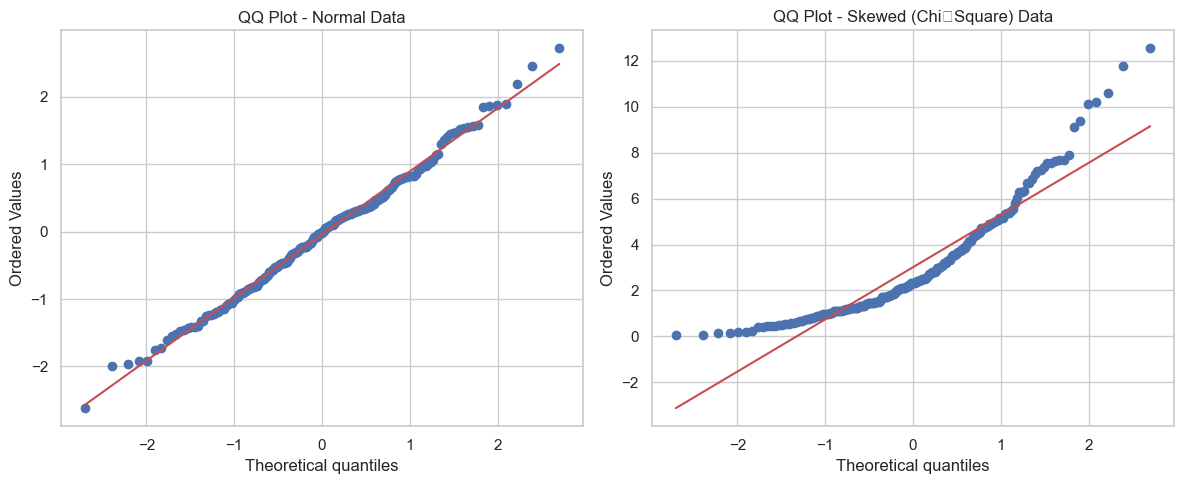

In [20]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate data: 200 points from a normal distribution
normal_data = np.random.normal(loc=0, scale=1, size=200)

# Generate data: 200 points from a chi-square distribution (skewed)
skewed_data = np.random.chisquare(df=3, size=200)

# Create QQ plots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal data QQ plot
stats.probplot(normal_data, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot - Normal Data")

# Skewed data QQ plot
stats.probplot(skewed_data, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot - Skewed (Chi‑Square) Data")

plt.tight_layout()
plt.show()